In [36]:
import pandas as pd

df = pd.read_csv("online_retail_cleaned.csv")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [37]:
import sqlite3

conn = sqlite3.connect("retail.db")
df.to_sql("online_retail", conn, if_exists="replace", index=False)


531282

In [38]:
import numpy as np

conditions = [
    (rfm_sql['r_score'] >= 4) & (rfm_sql['f_score'] >= 4) & (rfm_sql['m_score'] >= 4),
    (rfm_sql['f_score'] >= 4),
    (rfm_sql['r_score'] <= 2)
]
choices = ['Champions', 'Loyal Customers', 'At Risk']

rfm_sql['segment'] = np.select(conditions, choices, default='Others')
rfm_sql.head()

,CustomerID,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,18074.0,373.122917,1,489.60,1,2,2,122,At Risk
1,13747.0,373.092361,1,79.60,1,1,1,111,At Risk
2,12791.0,373.057639,1,192.60,1,1,1,111,At Risk
3,17908.0,373.045139,1,243.28,1,1,1,111,At Risk
4,16583.0,373.032639,1,233.45,1,1,1,111,At Risk


In [39]:
query = """
WITH rfm_values AS (
        SELECT
                CustomerID,
                JULIANDAY((SELECT MAX(InvoiceDate) FROM online_retail)) -
                JULIANDAY(MAX(InvoiceDate)) AS recency,
                COUNT(DISTINCT InvoiceNo) AS frequency,
                SUM(Quantity * UnitPrice) AS monetary
            FROM online_retail
            GROUP BY CustomerID
),
rfm_scores AS (
        SELECT
                *,
                NTILE(5) OVER (ORDER BY recency DESC) AS r_score,
                NTILE(5) OVER (ORDER BY frequency) AS f_score,
                NTILE(5) OVER (ORDER BY monetary) AS m_score
            FROM rfm_values
)
SELECT
    CustomerID,
        recency,
            frequency,
                monetary,
                    r_score,
                        f_score,
                            m_score,
                                r_score || f_score || m_score AS rfm_score
                                FROM rfm_scores;
                                """

rfm_sql = pd.read_sql(query, conn)
rfm_sql.head()

,CustomerID,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,18074.0,373.122917,1,489.60,1,2,2,122
1,13747.0,373.092361,1,79.60,1,1,1,111
2,12791.0,373.057639,1,192.60,1,1,1,111
3,17908.0,373.045139,1,243.28,1,1,1,111
4,16583.0,373.032639,1,233.45,1,1,1,111


In [40]:
import matplotlib.pyplot as plt


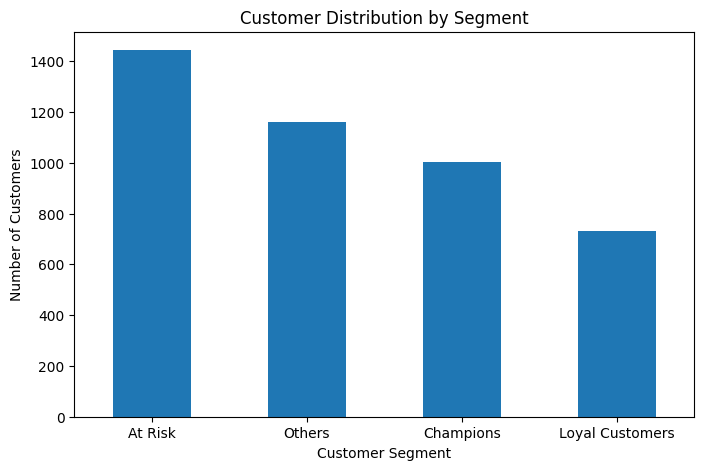

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure 'segment' column exists in rfm_sql
conditions = [
    (rfm_sql['r_score'] >= 4) & (rfm_sql['f_score'] >= 4) & (rfm_sql['m_score'] >= 4),
    (rfm_sql['f_score'] >= 4),
    (rfm_sql['r_score'] <= 2)
]
choices = ['Champions', 'Loyal Customers', 'At Risk']
rfm_sql['segment'] = np.select(conditions, choices, default='Others')

Segment_counts = rfm_sql['segment'].value_counts()

plt.figure(figsize=(8,5))
Segment_counts.plot(kind='bar')
plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

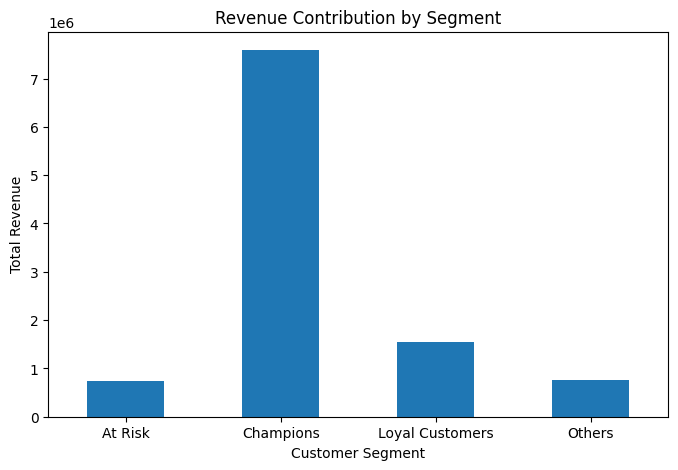

In [42]:
revenue_by_segment = rfm_sql.groupby('segment')['monetary'].sum()

plt.figure(figsize=(8,5))
revenue_by_segment.plot(kind='bar')
plt.title('Revenue Contribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()


In [43]:
## Segment Insights
#At Risk customers form the largest group, indicating churn potential.
#Champions generate high revenue despite lower customer count.
#Loyal customers show high frequency but moderate monetary value.
#Targeted marketing strategies can improve retention and revenue.
